# Random Forest
Apresentação do algoritmo Random Forest como uma extensão das árvores de decisão. Utilização do Random Forest para classificação de dados com Scikit-Learn.

**O que é o algoritmo de Random Forest?**

O algoritmo Random Forest é uma técnica de aprendizado de máquina que combina várias árvores de decisão para criar um modelo de previsão confiável.

Ele usa a ideia de "aprendizado em conjunto", onde as previsões de várias árvores são combinadas para obter resultados mais precisos e consistentes.

**Funcionamento do algoritmo de Random Forest:**

**1.   Dados de treinamento:** Usamos um conjunto de dados para treinar o modelo. Cada exemplo de treinamento inclui características e um valor-alvo que queremos prever.

**2.   Árvores de decisão:** O Random Forest cria várias árvores de decisão. Cada árvore é construída com uma parte aleatória dos dados e usa apenas algumas características. Isso traz diversidade e reduz a correlação entre as árvores.

**3.   Treinamento das árvores:** Cada árvore é treinada com um processo chamado "aprendizado supervisionado". Ela divide os dados com base nas características, buscando os melhores pontos de divisão para separar as classes ou fazer previsões numéricas. O processo continua até que os dados estejam bem divididos ou até um critério de parada seja alcançado.

**4.   Votação e previsão:** Após criar as árvores, o Random Forest combina as previsões de cada uma por votação (para classificação) ou por média (para regressão). A resposta final é determinada pela maioria das previsões (classificação) ou pela média das previsões (regressão).

**Aprendizado supervisionado em aprendizado de máquina:**

*   É uma abordagem onde um modelo é treinado para aprender a relação entre características e um valor-alvo.
*   O objetivo é fazer previsões ou tomar decisões precisas com base nas informações disponíveis.
*   O treinamento envolve fornecer exemplos rotulados ao modelo, com características conhecidas e seus valores-alvo correspondentes.
*   O modelo aprende a mapear as características para os valores-alvo durante o treinamento.
*   São utilizados algoritmos para construir o modelo, ajustando seus parâmetros com base nos dados de treinamento.
*   A escolha do algoritmo depende do problema e dos dados disponíveis.
*   Uma vez treinado, o modelo é usado para fazer previsões ou tomar decisões em novos dados de teste.
*   O desempenho do modelo é avaliado pela precisão de suas previsões ou decisões em relação aos valores reais dos dados de teste.

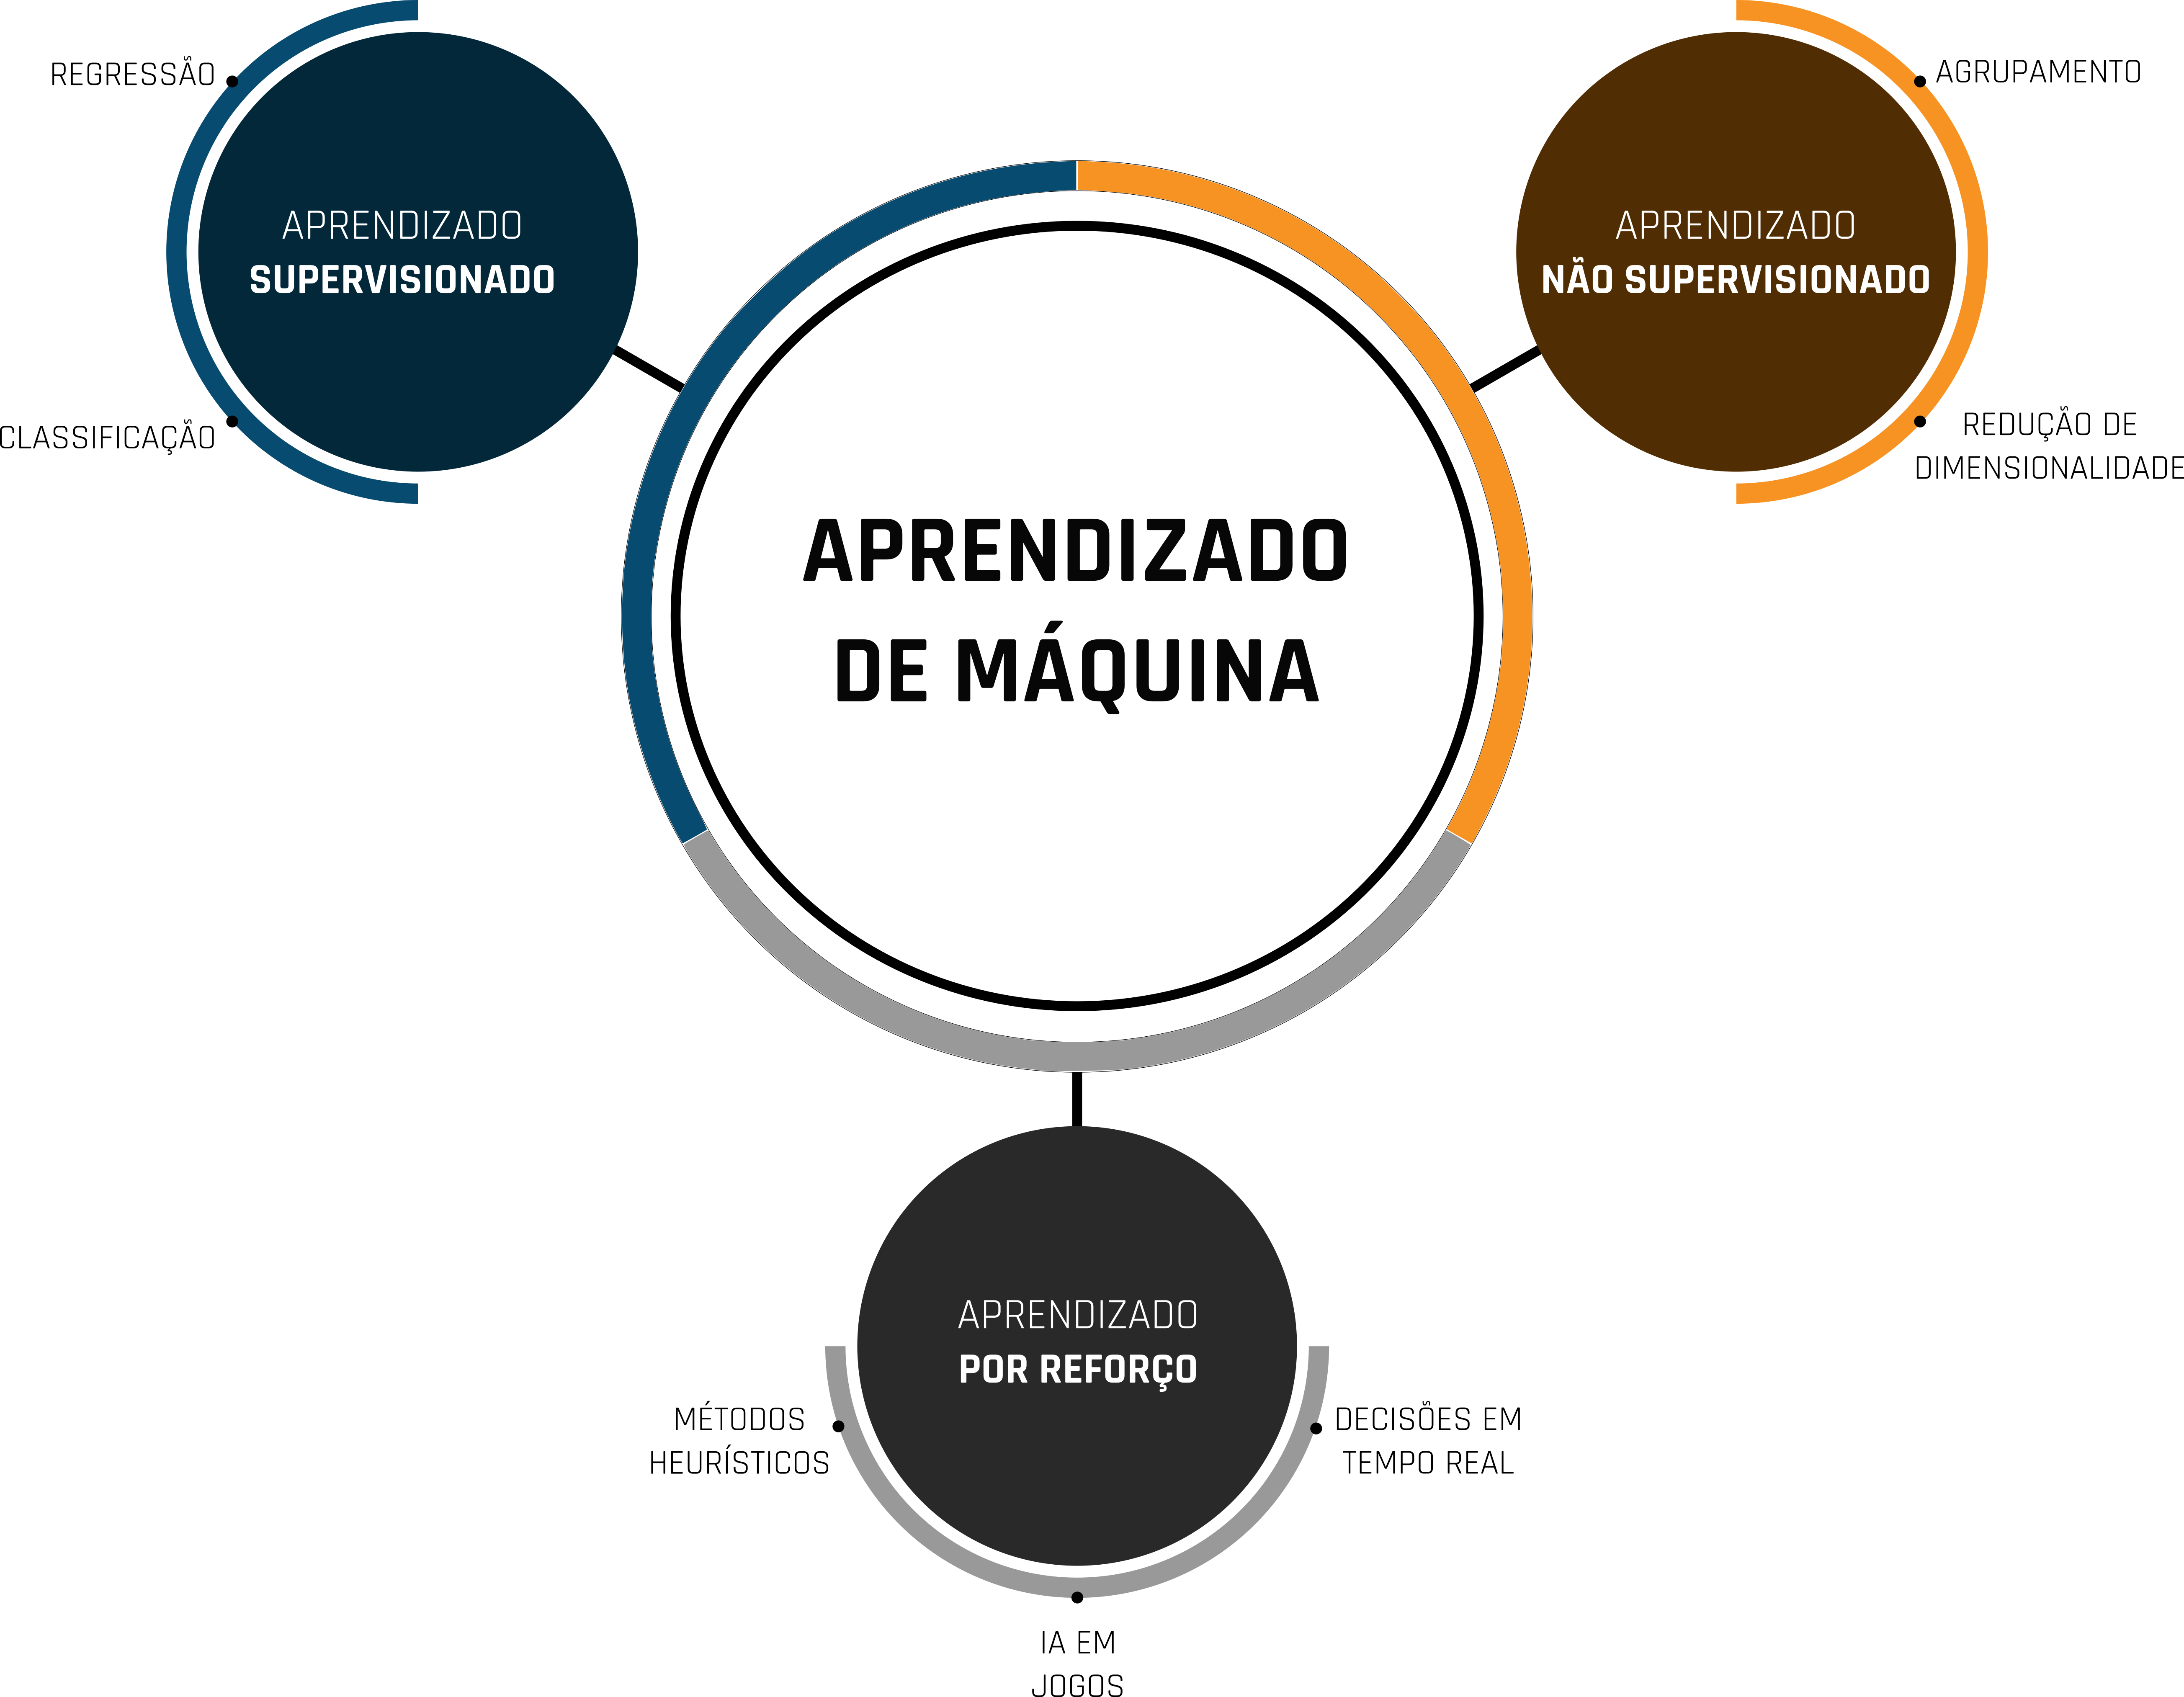

>**Classificação utilizando o algoritmo Random Forest**

**Passo a passo:**

1. **Importar as bibliotecas necessárias:** importar bibliotecas do scikit-learn, RandomForestClassifier, train_test_split, accuracy_score e pandas.

2. **Carregar o conjunto de dados:** carregar o conjunto de dados a partir de um arquivo CSV.

3. **Separar as características (X) e o valor-alvo (y):** separar os dados nas variáveis x e y.

4. **Dividir os dados em conjuntos de treinamento e teste:** 20% dos dados serão usados para teste.

5. **Criar um modelo Random Forest:** criar uma instância da classe RandomForestClassifier com 100 árvores na floresta.

6. **Treinar o modelo usando os dados de treinamento:** treinar o modelo Random Forest com os dados de treinamento.

7. **Fazer previsões com o conjunto de teste:** fazer previsões das classes correspondentes aos dados de teste usando o modelo treinado.

8. **Avaliar a precisão do modelo:** calcular a precisão do modelo comparando as previsões feitas pelo modelo (y_predicao) com os valores-alvo reais (y_teste) dos dados de teste.

9. **Imprimir a precisão do modelo:** imprimir o valor da precisão do modelo.

**Dados**

| idade | renda | emprestimo | fez_emprestimo |
|-------|-------|------------|----------------|
| 35    | 5000  | 1          | 0              |
| 42    | 7000  | 0          | 0              |
| 28    | 3000  | 1          | 1              |
| 55    | 10000 | 1          | 1              |
| 38    | 6000  | 0          | 0              |
| 31    | 4000  | 0          | 1              |
| 48    | 8000  | 1          | 0              |


**idade:** idade do cliente

**renda:** renda mensal do cliente

**emprestimo:** indica se o cliente já possui um empréstimo (1 para sim, 0 para não)

**fez_emprestimo:** indica se o cliente fez um empréstimo (1 para sim, 0 para não)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

dados = pd.read_csv('banco_dados.csv')

X = dados.drop('fez_emprestimo', axis=1)
y = dados['fez_emprestimo'] # Valor alvo

X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X, y,
                                                                  test_size=0.2,
                                                                  random_state=42)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

modelo.fit(X_treinamento, y_treinamento)

y_predicao = modelo.predict(X_teste)

precisao = accuracy_score(y_teste, y_predicao)

print("Precisão do modelo:",precisao)

Precisão do modelo: 0.75


**Previsão de novos dados**

Após treinar o modelo Random Forest, podemos usá-lo para fazer previsões e classificações em novos dados. Por exemplo, ao fornecer características de um novo cliente, o modelo pode prever se esse cliente é provável de fazer um empréstimo ou não.

In [ ]:
novo_cliente = pd.DataFrame({
    'idade':[22],
    'renda':[1000],
    'emprestimo':[1]
})
novo_cliente

,idade,renda,emprestimo
0,22,1000,1


In [ ]:
previsao = modelo.predict(novo_cliente)
print(f'A previsão para o novo cliente é: {previsao}')

A previsão para o novo cliente é: [1]


**Resultados**

0: Não faria empréstimo

1: Faria empréstimo

**Importância das características**

A importância das características é uma medida que a Random Forest fornece para mostrar quais características têm mais influência nas previsões do modelo. Isso nos ajuda a entender quais características são mais relevantes e pode ajudar a simplificar o modelo, removendo as características menos importantes.

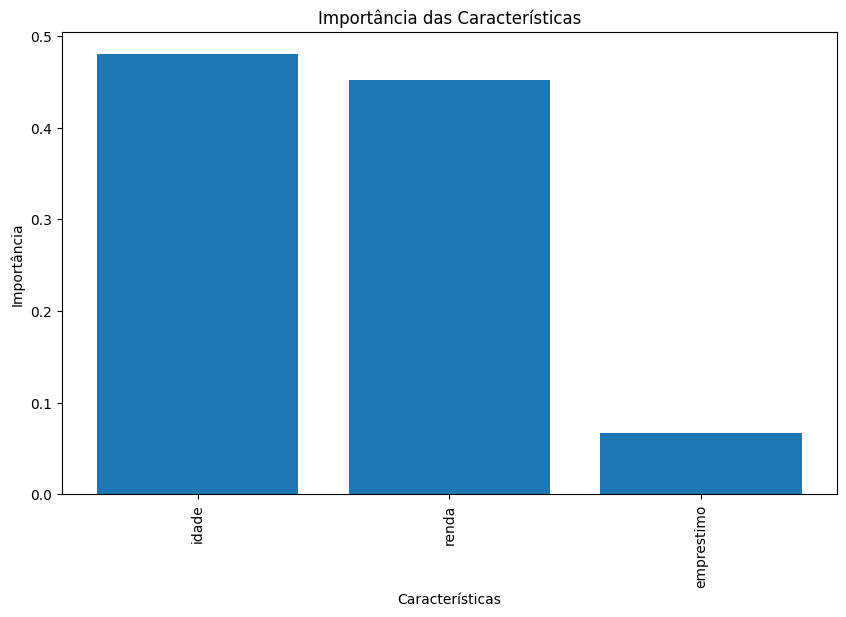

In [ ]:
import matplotlib.pyplot as plt

importancia_caracteristicas = modelo.feature_importances_

df_importancia = pd.DataFrame({'Características': X.columns,
                               'Importância': importancia_caracteristicas})
df_importancia = df_importancia.sort_values('Importância',ascending=False)

plt.figure(figsize=(10,6))
plt.bar(df_importancia['Características'],df_importancia['Importância'])
plt.xticks(rotation=90)
plt.xlabel('Características')
plt.ylabel('Importância')
plt.title('Importância das Características')
plt.show()